## Batters Key Parameters — Statistical Analysis

This notebook performs a complete statistical analysis of `batters_key_parameters.csv`:

- Data loading + type cleaning
- Data quality (missing values, duplicates)
- Descriptive statistics (overall and by `Batting_Type`)
- Distribution + outlier analysis
- Correlation + multicollinearity checks
- Role-wise hypothesis testing (Opener vs Middle Order vs Finisher)
- Modeling-oriented analysis (regression + feature importance)
- PCA + clustering to identify batter archetypes

### Important note about columns
This dataset is produced by `data/ipl/key_parameter.py`. In that script:
- For **Openers**, `Balls_per_Boundary_PP` and `Dot_Balls_PP_per_Innings` represent **Powerplay** behavior.
- For **Finishers**, those same columns are overwritten to represent **Death overs** behavior.

So interpret `*_PP_*` columns as **phase-specific** and dependent on `Batting_Type`.



In [1]:
# If you run into missing packages, uncomment and run:
# %pip install -q pandas numpy matplotlib seaborn scipy statsmodels scikit-learn

from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)



In [2]:
# --- Robust data loading ---

def find_csv() -> Path:
    candidates = [
        # Absolute path (your workspace)
        Path(r"C:\Users\Dell\Desktop\IPL_Auction_Tool\data\ipl\batters_key_parameters.csv"),
        # Relative to current working directory
        Path("data") / "ipl" / "batters_key_parameters.csv",
    ]

    for p in candidates:
        if p.exists():
            return p

    # Fallback: search under cwd
    hits = list(Path.cwd().rglob("batters_key_parameters.csv"))
    if hits:
        return hits[0]

    raise FileNotFoundError(
        "Could not find batters_key_parameters.csv. "
        "Expected it at data/ipl/batters_key_parameters.csv under the project root."
    )

csv_path = find_csv()
csv_path



WindowsPath('C:/Users/Dell/Desktop/IPL_Auction_Tool/data/ipl/batters_key_parameters.csv')

In [3]:
# Load
raw = pd.read_csv(csv_path)
raw.head()


,Player,Batting_Type,Innings,Average,Strike_Rate,Balls_per_Boundary_PP,Balls_per_Boundary_Overall,Dot_Balls_PP_per_Innings,Dot_Balls_per_Innings,Boundaries_per_Innings,Total_Runs
0,Abdul Samad,Finisher,12,18.22,176.34,4.07,4.23,1.08,2.25,1.83,164
1,Abhinav Manohar,Finisher,5,12.20,100.00,6.20,10.17,2.20,5.80,1.20,61
2,Abhishek Sharma,Opener,13,36.58,195.11,3.28,3.04,4.69,6.00,3.54,439
3,Abishek Porel,Opener,13,23.15,146.83,4.37,5.12,3.23,4.62,2.08,301
4,Angkrish Raghuvanshi,Middle Order,11,33.33,140.19,3.31,5.63,1.36,5.27,3.45,300


In [4]:
# Basic schema + cleaning

df = raw.copy()

# Standardize column names (keep original names, but strip whitespace)
df.columns = [c.strip() for c in df.columns]

# Strip string columns
for c in ["Player", "Batting_Type"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# Convert numerics
numeric_cols = [
    "Innings",
    "Average",
    "Strike_Rate",
    "Balls_per_Boundary_PP",
    "Balls_per_Boundary_Overall",
    "Dot_Balls_PP_per_Innings",
    "Dot_Balls_per_Innings",
    "Boundaries_per_Innings",
    "Total_Runs",
]

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Sanity derived metrics (often more stable for modeling)
df["Runs_per_Innings"] = df["Total_Runs"] / df["Innings"]

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.info()


Shape: (98, 12)
Columns: ['Player', 'Batting_Type', 'Innings', 'Average', 'Strike_Rate', 'Balls_per_Boundary_PP', 'Balls_per_Boundary_Overall', 'Dot_Balls_PP_per_Innings', 'Dot_Balls_per_Innings', 'Boundaries_per_Innings', 'Total_Runs', 'Runs_per_Innings']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Player                      98 non-null     object 
 1   Batting_Type                98 non-null     object 
 2   Innings                     98 non-null     int64  
 3   Average                     98 non-null     float64
 4   Strike_Rate                 98 non-null     float64
 5   Balls_per_Boundary_PP       92 non-null     float64
 6   Balls_per_Boundary_Overall  95 non-null     float64
 7   Dot_Balls_PP_per_Innings    98 non-null     float64
 8   Dot_Balls_per_Innings       98 non-null     float64
 9   Boundari

In [5]:
# Data quality checks

# Duplicates
if "Player" in df.columns:
    dup_players = df["Player"].duplicated().sum()
    print("Duplicate Player rows:", dup_players)

# Missing values
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
missing.to_frame("missing_fraction")



Duplicate Player rows: 0


,missing_fraction
Balls_per_Boundary_PP,0.061224
Balls_per_Boundary_Overall,0.030612


In [6]:
# Overall descriptive statistics

summary = df[numeric_cols + ["Runs_per_Innings"]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
summary["missing"] = df[numeric_cols + ["Runs_per_Innings"]].isna().sum().values
summary.sort_values("missing", ascending=False)



,count,mean,std,min,5%,25%,50%,75%,95%,max,missing
Balls_per_Boundary_PP,92.0,5.080543,2.840690,2.250000,2.6155,3.450000,4.185000,5.925000,8.648500,25.00,6
Balls_per_Boundary_Overall,95.0,5.381895,2.629848,2.880000,3.2470,4.130000,4.810000,5.820000,8.173000,25.00,3
Innings,98.0,10.132653,3.605945,5.000000,5.0000,7.000000,11.000000,13.000000,15.000000,18.00,0
Average,98.0,27.466735,13.807894,1.750000,6.0000,19.137500,26.980000,34.275000,53.855500,65.18,0
Strike_Rate,98.0,146.039286,30.586239,41.180000,93.6415,133.180000,149.910000,165.260000,188.337500,208.26,0
Dot_Balls_PP_per_Innings,98.0,2.551429,1.722674,0.200000,0.5850,1.150000,2.000000,4.127500,5.804500,6.60,0
Dot_Balls_per_Innings,98.0,4.936531,1.980092,0.800000,1.6170,3.672500,5.090000,5.982500,8.097000,9.85,0
Boundaries_per_Innings,98.0,2.679490,1.414498,0.000000,0.4000,1.762500,2.825000,3.520000,5.022500,6.69,0
Total_Runs,98.0,247.244898,181.441312,6.000000,17.4000,106.750000,220.500000,348.250000,607.450000,759.00,0
Runs_per_Innings,98.0,21.879210,11.307145,1.166667,3.4800,14.286364,22.071429,27.828571,41.676923,50.60,0


In [7]:
# By-role descriptive statistics

assert "Batting_Type" in df.columns, "Expected Batting_Type column"

by_role = (
    df.groupby("Batting_Type")[numeric_cols + ["Runs_per_Innings"]]
      .agg(["count", "mean", "median", "std"])
      .sort_values(("Innings", "count"), ascending=False)
)
by_role


Innings                             Average                              Strike_Rate                                  \
               count       mean median       std   count       mean median        std       count        mean   median        std   
Batting_Type                                                                                                                        
Finisher          45   8.866667    8.0  3.144982      45  21.988000  21.20  13.409049          45  138.095333  142.860  36.916062   
Middle Order      27  11.222222   11.0  3.411895      27  32.433704  27.44  13.603560          27  150.900741  150.620  19.663358   
Opener            26  11.192308   12.5  3.949878      26  31.791154  30.74  11.433209          26  154.740000  154.165  24.725083   

             Balls_per_Boundary_PP                            Balls_per_Boundary_Overall                             \
                             count      mean median       std                      count      mean median       std   
Batting_Type                                                                                                          
Finisher                        41  5.603171   4.17  3.783182                         42  6.211905  5.485  3.602470   
Middle Order                    25  5.087600   4.60  1.992411                         27  4.991111  4.710  1.104220   
Opener                          26  4.249615   4.05  1.223168                         26  4.446923  4.260  1.105191   

             Dot_Balls_PP_per_Innings                            Dot_Balls_per_Innings                            Boundaries_per_Innings  \
                                count      mean median       std                 count      mean median       std                  count   
Batting_Type                                                                                                                               
Finisher                           45  1.492889   1.38  0.661612                    45  3.406222   3.50  1.457564                     45   
Middle Order                       27  1.935926   1.81  1.125868                    27  5.678889   5.40  1.130484                     27   
Opener                             26  5.022692   5.00  0.805067                    26  6.814231   6.87  1.291146                     26   

                                        Total_Runs                                Runs_per_Innings                                   
                  mean median       std      count        mean median         std            count       mean     median        std  
Batting_Type                                                                                                                         
Finisher      1.858222  1.830  1.186723         45  142.444444  118.0  106.473547               45  14.393747  15.300000   8.525712  
Middle Order  3.706667  3.450  1.290456         27  316.074074  291.0  168.013032               27  26.718734  25.272727   8.247995  
Opener        3.034231  3.155  1.033523         26  357.153846  337.5  202.420492               26  29.809161  30.638889  10.287409

In [8]:
# Quick role counts

df["Batting_Type"].value_counts(dropna=False)


Batting_Type
Finisher        45
Middle Order    27
Opener          26
Name: count, dtype: int64

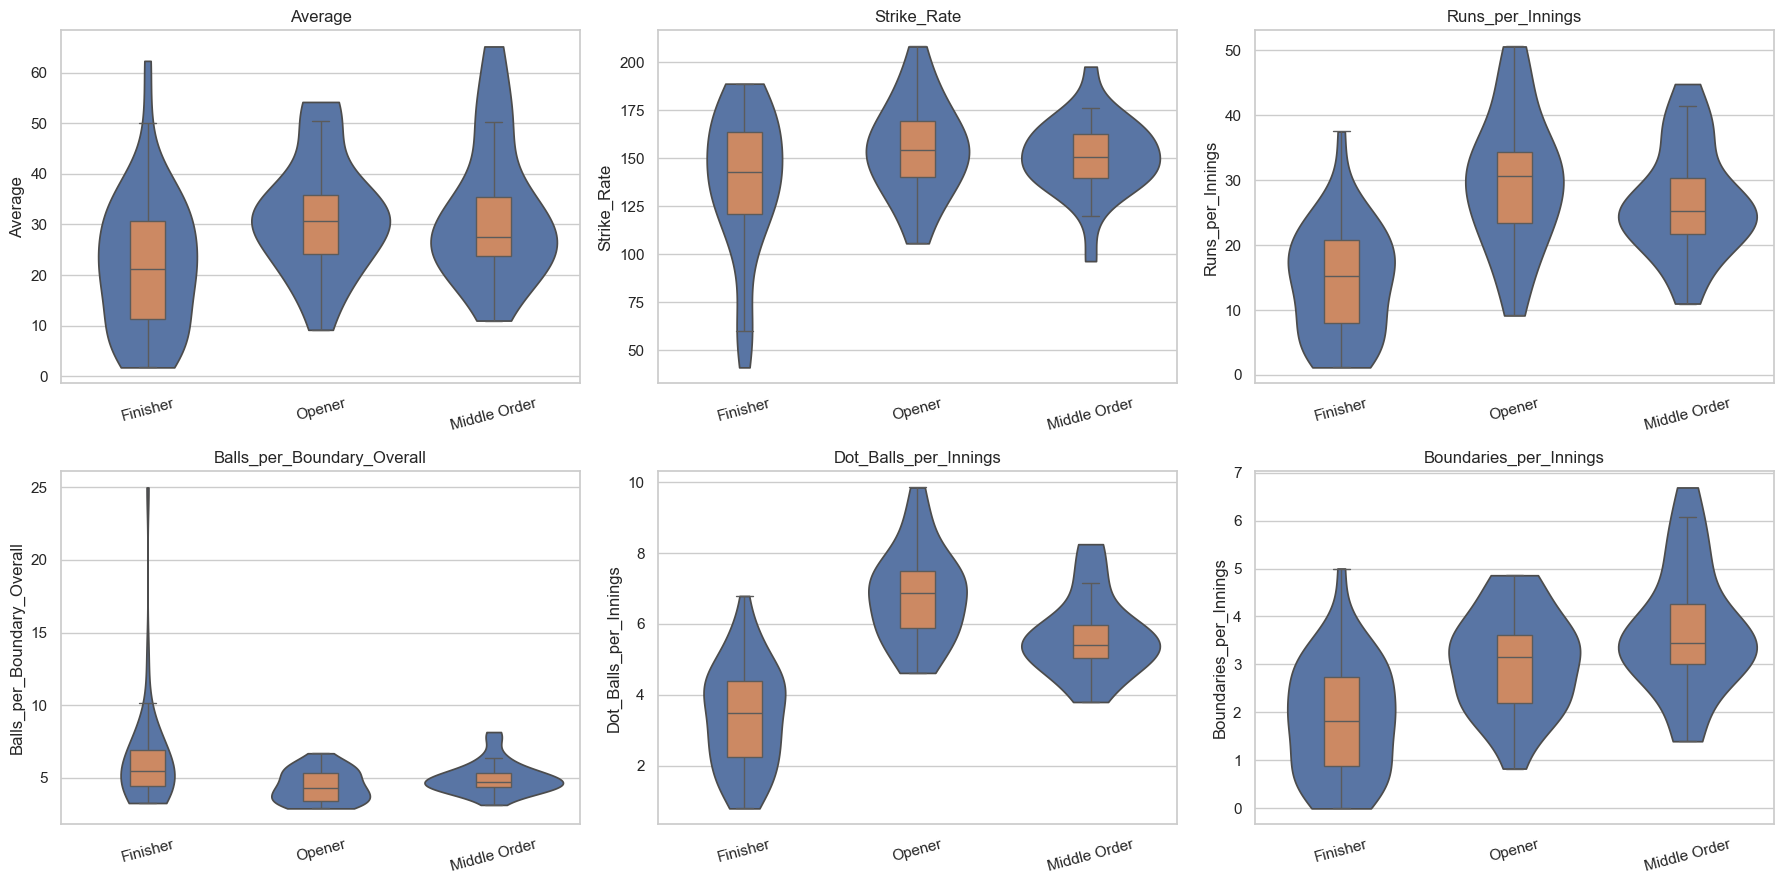

In [9]:
# Visual comparisons by role (box/violin)

plot_metrics = [
    "Average",
    "Strike_Rate",
    "Runs_per_Innings",
    "Balls_per_Boundary_Overall",
    "Dot_Balls_per_Innings",
    "Boundaries_per_Innings",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for ax, m in zip(axes, plot_metrics):
    tmp = df[["Batting_Type", m]].dropna()
    sns.violinplot(data=tmp, x="Batting_Type", y=m, inner=None, cut=0, ax=ax)
    sns.boxplot(data=tmp, x="Batting_Type", y=m, width=0.2, showfliers=False, ax=ax)
    ax.set_title(m)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


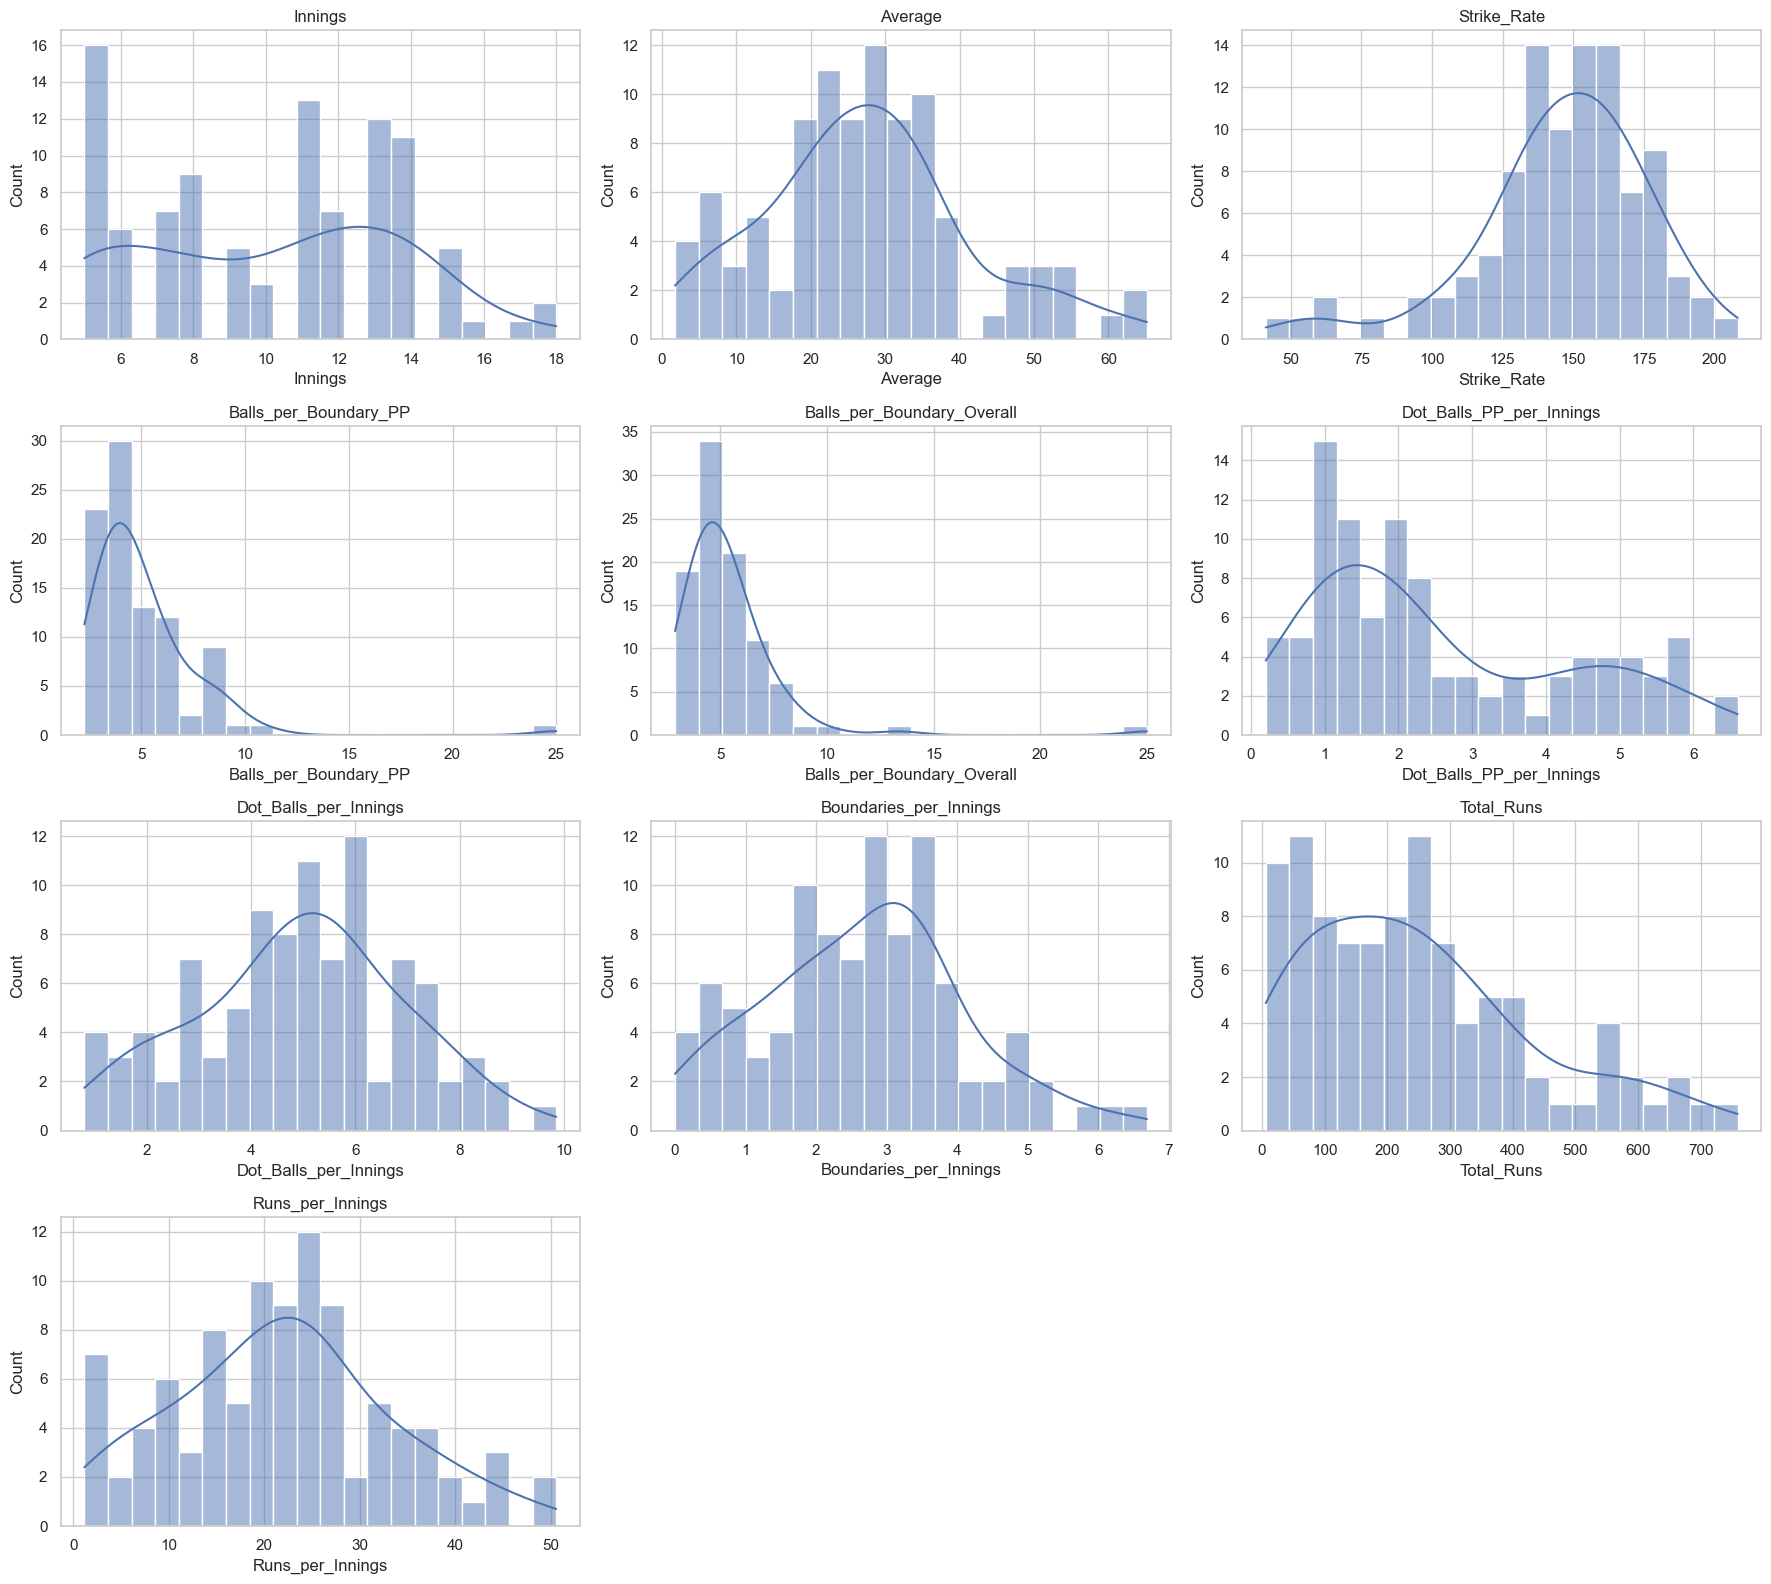

In [10]:
# Univariate distributions (overall)

num_for_dist = [c for c in (numeric_cols + ["Runs_per_Innings"]) if c in df.columns]

n = len(num_for_dist)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, c in enumerate(num_for_dist):
    ax = axes[i]
    x = df[c].dropna()
    sns.histplot(x, kde=True, ax=ax, bins=20)
    ax.set_title(c)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [11]:
# Outlier scan using robust z-scores (MAD)

def robust_z(x: pd.Series) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce")
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if mad == 0 or np.isnan(mad):
        return pd.Series(np.nan, index=x.index)
    return 0.6745 * (x - med) / mad

outlier_metrics = [
    "Strike_Rate",
    "Average",
    "Runs_per_Innings",
    "Balls_per_Boundary_Overall",
    "Dot_Balls_per_Innings",
    "Boundaries_per_Innings",
]

rows = []
for m in outlier_metrics:
    z = robust_z(df[m])
    tmp = df[["Player", "Batting_Type", m]].copy()
    tmp["robust_z"] = z
    # biggest absolute outliers
    rows.append(tmp.reindex(z.abs().sort_values(ascending=False).head(10).index).assign(metric=m))

outliers = pd.concat(rows, ignore_index=True)
outliers.sort_values(["metric", "robust_z"], ascending=[True, False]).head(40)



,Player,Batting_Type,Strike_Rate,robust_z,metric,Average,Runs_per_Innings,Balls_per_Boundary_Overall,Dot_Balls_per_Innings,Boundaries_per_Innings
10,Suryakumar Yadav,Middle Order,NaN,3.522338,Average,65.18,NaN,NaN,NaN,NaN
11,Tim David,Finisher,NaN,3.259545,Average,62.33,NaN,NaN,NaN,NaN
12,Rahul,Middle Order,NaN,3.106481,Average,60.67,NaN,NaN,NaN,NaN
13,Sai Sudharsan,Opener,NaN,2.510818,Average,54.21,NaN,NaN,NaN,NaN
14,Shubman Gill,Opener,NaN,2.507130,Average,54.17,NaN,NaN,NaN,NaN
15,Buttler,Middle Order,NaN,2.473013,Average,53.80,NaN,NaN,NaN,NaN
19,Kohli,Opener,NaN,2.172416,Average,50.54,NaN,NaN,NaN,NaN
18,Mitchell Starc,Finisher,NaN,-2.211143,Average,3.00,NaN,NaN,NaN,NaN
17,Hasaranga,Finisher,NaN,-2.321792,Average,1.80,NaN,NaN,NaN,NaN
16,Noor Ahmad,Finisher,NaN,-2.326403,Average,1.75,NaN,NaN,NaN,NaN


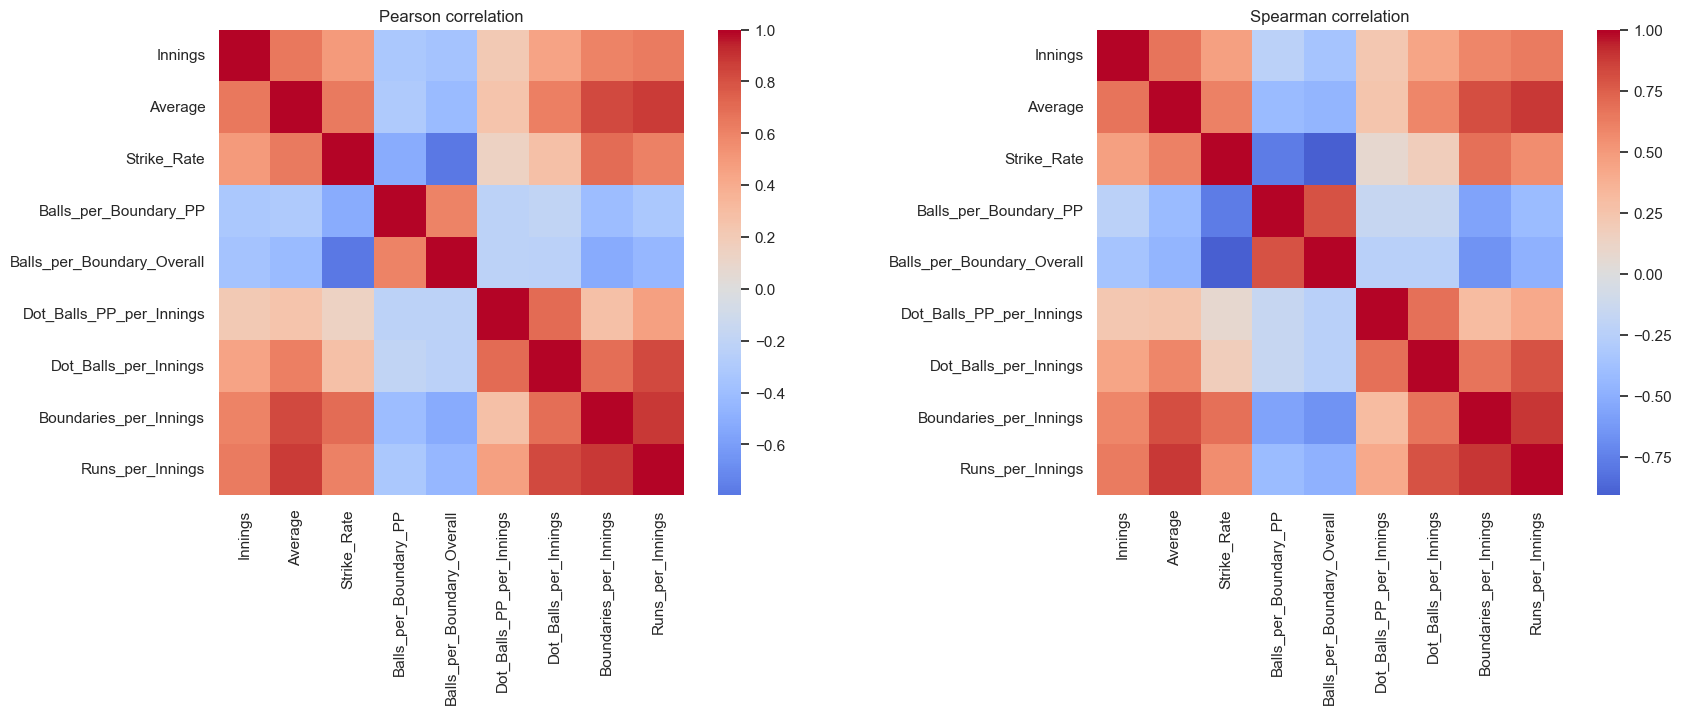

,a,b,corr,abs_corr
63,Boundaries_per_Innings,Runs_per_Innings,0.881153,0.881153
15,Average,Runs_per_Innings,0.878837,0.878837
14,Average,Boundaries_per_Innings,0.827551,0.827551
55,Dot_Balls_per_Innings,Runs_per_Innings,0.824807,0.824807
19,Strike_Rate,Balls_per_Boundary_Overall,-0.796785,0.796785
45,Dot_Balls_PP_per_Innings,Dot_Balls_per_Innings,0.703583,0.703583
22,Strike_Rate,Boundaries_per_Innings,0.694667,0.694667
54,Dot_Balls_per_Innings,Boundaries_per_Innings,0.684237,0.684237
0,Innings,Average,0.655535,0.655535
9,Average,Strike_Rate,0.635657,0.635657


In [12]:
# Correlation analysis (Pearson + Spearman)

corr_cols = [c for c in num_for_dist if c != "Total_Runs"]  # avoid trivial correlation with Runs_per_Innings etc.

pearson = df[corr_cols].corr(method="pearson")
spearman = df[corr_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(pearson, ax=axes[0], cmap="coolwarm", center=0, square=True)
axes[0].set_title("Pearson correlation")

sns.heatmap(spearman, ax=axes[1], cmap="coolwarm", center=0, square=True)
axes[1].set_title("Spearman correlation")

plt.tight_layout()
plt.show()

# Top absolute correlations (excluding self)
def top_pairs(cmat: pd.DataFrame, k: int = 15):
    c = cmat.copy()
    np.fill_diagonal(c.values, np.nan)
    pairs = (
        c.stack()
         .rename("corr")
         .reset_index()
         .rename(columns={"level_0": "a", "level_1": "b"})
    )
    pairs["abs_corr"] = pairs["corr"].abs()
    # remove duplicates (a,b) vs (b,a)
    pairs["pair"] = pairs.apply(lambda r: "|".join(sorted([r["a"], r["b"]])), axis=1)
    pairs = pairs.drop_duplicates("pair").drop(columns=["pair"]).sort_values("abs_corr", ascending=False)
    return pairs.head(k)

top_pairs(pearson, 15)



In [13]:
# Multicollinearity (VIF)

try:
    import statsmodels.api as sm
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except Exception as e:
    raise ImportError(
        "statsmodels is required for VIF. Install with: %pip install statsmodels"
    ) from e

vif_features = [
    "Innings",
    "Average",
    "Strike_Rate",
    "Balls_per_Boundary_PP",
    "Balls_per_Boundary_Overall",
    "Dot_Balls_PP_per_Innings",
    "Dot_Balls_per_Innings",
    "Boundaries_per_Innings",
    "Runs_per_Innings",
]

X_vif = df[vif_features].copy()
# Simple median impute for VIF computation
X_vif = X_vif.apply(lambda s: s.fillna(s.median()), axis=0)
X_vif = sm.add_constant(X_vif)

vif = []
for i, col in enumerate(X_vif.columns):
    if col == "const":
        continue
    vif.append({"feature": col, "VIF": float(variance_inflation_factor(X_vif.values, i))})

pd.DataFrame(vif).sort_values("VIF", ascending=False)



,feature,VIF
8,Runs_per_Innings,13.984987
6,Dot_Balls_per_Innings,8.583047
7,Boundaries_per_Innings,7.149089
1,Average,5.846960
2,Strike_Rate,3.391904
5,Dot_Balls_PP_per_Innings,2.972503
4,Balls_per_Boundary_Overall,1.866755
0,Innings,1.859206
3,Balls_per_Boundary_PP,1.313658


In [14]:
# Hypothesis testing: do roles differ on key metrics?
# Uses ANOVA when assumptions look OK; otherwise Kruskal-Wallis.
# Also reports effect sizes and pairwise comparisons with Holm correction.

from itertools import combinations

def cohen_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) < 2 or len(y) < 2:
        return np.nan
    nx, ny = len(x), len(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    s = np.sqrt(((nx - 1) * vx + (ny - 1) * vy) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / s if s > 0 else np.nan

# Cliff's delta (non-parametric effect size)
def cliffs_delta(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    # O(n*m) but dataset is small
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    return (gt - lt) / (len(x) * len(y))

def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m)
    running = 0
    for i, idx in enumerate(order):
        adj_p = (m - i) * pvals[idx]
        running = max(running, adj_p)
        adj[idx] = min(running, 1.0)
    return adj

metrics_for_tests = [
    "Average",
    "Strike_Rate",
    "Runs_per_Innings",
    "Balls_per_Boundary_Overall",
    "Dot_Balls_per_Innings",
    "Boundaries_per_Innings",
]

groups = [g for g in df["Batting_Type"].dropna().unique().tolist()]
groups



['Finisher', 'Opener', 'Middle Order']

In [15]:
test_rows = []
pairwise_rows = []

for m in metrics_for_tests:
    data = df[["Batting_Type", m]].dropna()
    # group arrays
    arrays = [data.loc[data["Batting_Type"] == g, m].values.astype(float) for g in groups]
    ns = [len(a) for a in arrays]

    # Normality checks (Shapiro) only meaningful for small/medium n
    shapiro_ps = []
    for a in arrays:
        if 3 <= len(a) <= 5000:
            shapiro_ps.append(stats.shapiro(a).pvalue)
        else:
            shapiro_ps.append(np.nan)

    normalish = all([(p > 0.05) for p in shapiro_ps if not np.isnan(p)])

    # Variance check (Levene)
    lev_p = stats.levene(*arrays, center="median").pvalue if all(n >= 2 for n in ns) else np.nan
    equal_varish = (lev_p > 0.05) if not np.isnan(lev_p) else False

    if normalish and equal_varish and all(n >= 5 for n in ns):
        # ANOVA
        stat, p = stats.f_oneway(*arrays)
        method = "ANOVA"
        # eta^2
        y = data[m].values
        grand_mean = np.mean(y)
        ss_between = sum([len(a) * (np.mean(a) - grand_mean) ** 2 for a in arrays])
        ss_total = np.sum((y - grand_mean) ** 2)
        effect = ss_between / ss_total if ss_total > 0 else np.nan
        effect_name = "eta_sq"

        # pairwise Welch t-tests (safer than pooled), Holm
        pvals = []
        pairs = []
        for g1, g2 in combinations(groups, 2):
            x = data.loc[data["Batting_Type"] == g1, m].values
            y2 = data.loc[data["Batting_Type"] == g2, m].values
            tstat, tp = stats.ttest_ind(x, y2, equal_var=False, nan_policy="omit")
            pvals.append(tp)
            pairs.append((g1, g2, float(np.nanmean(x) - np.nanmean(y2)), float(cohen_d(x, y2))))
        adj = holm_adjust(pvals)
        for (g1, g2, mean_diff, d), raw_p, adj_p in zip(pairs, pvals, adj):
            pairwise_rows.append(
                {
                    "metric": m,
                    "method": "Welch t-test",
                    "group1": g1,
                    "group2": g2,
                    "mean_diff(g1-g2)": mean_diff,
                    "effect_size": d,
                    "effect": "cohen_d",
                    "p": raw_p,
                    "p_holm": adj_p,
                }
            )

    else:
        # Kruskal-Wallis
        stat, p = stats.kruskal(*arrays, nan_policy="omit")
        method = "Kruskal"
        # epsilon^2 effect size approximation
        n_total = sum(ns)
        k = len(arrays)
        effect = (stat - k + 1) / (n_total - k) if (n_total - k) > 0 else np.nan
        effect_name = "epsilon_sq"

        # pairwise Mann-Whitney U, Holm
        pvals = []
        pairs = []
        for g1, g2 in combinations(groups, 2):
            x = data.loc[data["Batting_Type"] == g1, m].values
            y2 = data.loc[data["Batting_Type"] == g2, m].values
            if len(x) == 0 or len(y2) == 0:
                continue
            u, up = stats.mannwhitneyu(x, y2, alternative="two-sided")
            pvals.append(up)
            pairs.append((g1, g2, float(np.nanmedian(x) - np.nanmedian(y2)), float(cliffs_delta(x, y2))))
        if pvals:
            adj = holm_adjust(pvals)
            for (g1, g2, med_diff, cd), raw_p, adj_p in zip(pairs, pvals, adj):
                pairwise_rows.append(
                    {
                        "metric": m,
                        "method": "Mann-Whitney U",
                        "group1": g1,
                        "group2": g2,
                        "median_diff(g1-g2)": med_diff,
                        "effect_size": cd,
                        "effect": "cliffs_delta",
                        "p": raw_p,
                        "p_holm": adj_p,
                    }
                )

    test_rows.append(
        {
            "metric": m,
            "test": method,
            "stat": stat,
            "p": p,
            "normalish": normalish,
            "levene_p": lev_p,
            "effect": effect,
            "effect_name": effect_name,
            **{f"n_{g}": int(n) for g, n in zip(groups, ns)},
        }
    )

overall_tests = pd.DataFrame(test_rows).sort_values("p")
overall_tests


,metric,test,stat,p,normalish,levene_p,effect,effect_name,n_Finisher,n_Opener,n_Middle Order
4,Dot_Balls_per_Innings,ANOVA,59.785398,1.556923e-17,True,0.110828,0.557256,eta_sq,45,26,27
2,Runs_per_Innings,ANOVA,29.879699,8.573583e-11,True,0.454399,0.386144,eta_sq,45,26,27
5,Boundaries_per_Innings,ANOVA,22.356116,1.104678e-08,True,0.771040,0.320031,eta_sq,45,26,27
0,Average,Kruskal,12.598858,1.837354e-03,False,0.569392,0.111567,epsilon_sq,45,26,27
3,Balls_per_Boundary_Overall,Kruskal,9.633723,8.092146e-03,False,0.044384,0.082975,epsilon_sq,42,26,27
1,Strike_Rate,Kruskal,2.997164,2.234468e-01,False,0.011827,0.010496,epsilon_sq,45,26,27


In [16]:
pairwise = pd.DataFrame(pairwise_rows)

# Show the most significant pairwise differences (after Holm correction)
if len(pairwise):
    pairwise.sort_values(["p_holm", "metric"]).head(25)
else:
    print("No pairwise comparisons computed.")


In [18]:
# PCA (archetype space) + KMeans clustering

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = [
    "Average",
    "Strike_Rate",
    "Balls_per_Boundary_PP",
    "Balls_per_Boundary_Overall",
    "Dot_Balls_PP_per_Innings",
    "Dot_Balls_per_Innings",
    "Boundaries_per_Innings",
    "Runs_per_Innings",
]
cluster_features = [c for c in cluster_features if c in df.columns]

Z = df[cluster_features].copy()
Z = Z.apply(lambda s: s.fillna(s.median()), axis=0)

scaler = StandardScaler()
Zs = scaler.fit_transform(Z)

pca = PCA(n_components=min(5, Zs.shape[1]))
pcs = pca.fit_transform(Zs)

expl = pd.Series(pca.explained_variance_ratio_, index=[f"PC{i+1}" for i in range(pca.n_components_)])
expl.to_frame("explained_variance_ratio")



,explained_variance_ratio
PC1,0.558764
PC2,0.169761
PC3,0.115939
PC4,0.080188
PC5,0.035321


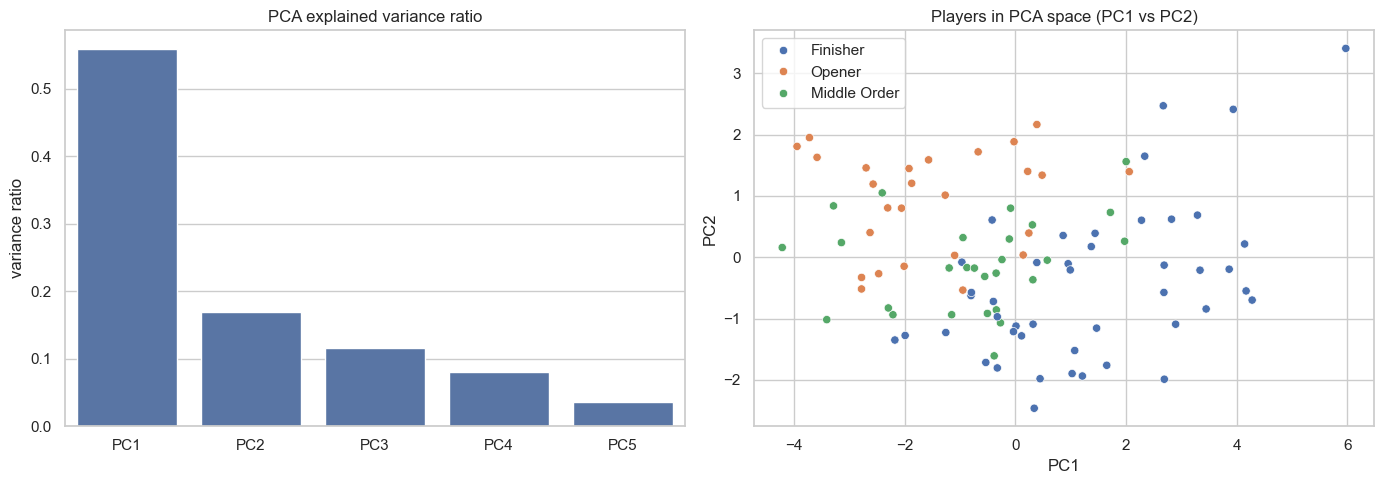

,PC1_loading,PC2_loading
Balls_per_Boundary_Overall,0.283242,0.436401
Balls_per_Boundary_PP,0.205930,0.330052
Dot_Balls_PP_per_Innings,-0.242379,0.506523
Strike_Rate,-0.354515,-0.420938
Dot_Balls_per_Innings,-0.368254,0.490735
Average,-0.411438,-0.012139
Boundaries_per_Innings,-0.434594,-0.057132
Runs_per_Innings,-0.446290,0.150444


In [19]:
# PCA plots: explained variance + PC1/PC2 scatter (colored by role)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=expl.index, y=expl.values, ax=ax[0])
ax[0].set_title("PCA explained variance ratio")
ax[0].set_xlabel("")
ax[0].set_ylabel("variance ratio")

pc_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"])
pc_df["Batting_Type"] = df["Batting_Type"].values
pc_df["Player"] = df["Player"].values

sns.scatterplot(data=pc_df, x="PC1", y="PC2", hue="Batting_Type", ax=ax[1])
ax[1].set_title("Players in PCA space (PC1 vs PC2)")
ax[1].legend(loc="best")

plt.tight_layout()
plt.show()

# PCA loadings
loadings = pd.DataFrame(pca.components_[:2].T, index=cluster_features, columns=["PC1_loading", "PC2_loading"])
loadings.sort_values("PC1_loading", ascending=False)



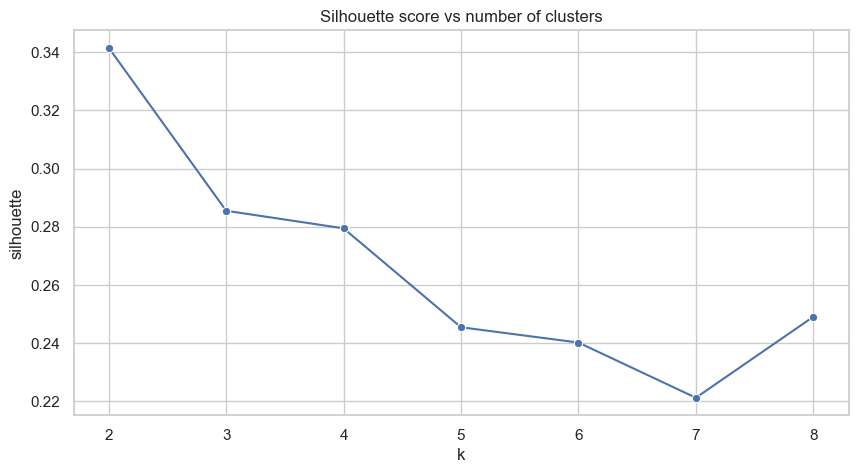

2

In [20]:
# KMeans: pick k via silhouette

sil = []
ks = list(range(2, min(9, len(df) - 1)))
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(Zs)
    sil.append(silhouette_score(Zs, labels))

sil_df = pd.DataFrame({"k": ks, "silhouette": sil})

sns.lineplot(data=sil_df, x="k", y="silhouette", marker="o")
plt.title("Silhouette score vs number of clusters")
plt.show()

best_k = int(sil_df.sort_values("silhouette", ascending=False).iloc[0]["k"]) if len(sil_df) else 3
best_k


In [21]:
# Fit KMeans and summarize clusters

km = KMeans(n_clusters=best_k, n_init=50, random_state=42)
cluster_labels = km.fit_predict(Zs)

clustered = df[["Player", "Batting_Type"] + cluster_features].copy()
clustered["cluster"] = cluster_labels

# Cluster sizes and role mix
cluster_sizes = clustered["cluster"].value_counts().sort_index()
role_mix = pd.crosstab(clustered["cluster"], clustered["Batting_Type"], normalize="index")

cluster_sizes.to_frame("n")



,n
cluster,
0,66
1,32


In [22]:
role_mix


Batting_Type,Finisher,Middle Order,Opener
cluster,,,
0,0.272727,0.348485,0.378788
1,0.843750,0.125000,0.031250


In [23]:
# Cluster profiles (mean z-scored features back to original scale summary)

cluster_profile = (
    clustered.groupby("cluster")[cluster_features]
             .agg(["mean", "median"])
)
cluster_profile


Average         Strike_Rate          Balls_per_Boundary_PP        Balls_per_Boundary_Overall        Dot_Balls_PP_per_Innings  \
              mean  median        mean   median                  mean median                       mean median                     mean   
cluster                                                                                                                                   
0        33.722121  31.585  158.592879  157.245              4.090312  3.985                    4.51303   4.43                 3.031818   
1        14.565000  13.425  120.147500  127.120              7.343929  6.535                    7.35931   6.54                 1.560625   

               Dot_Balls_per_Innings        Boundaries_per_Innings        Runs_per_Innings             
        median                  mean median                   mean median             mean     median  
cluster                                                                                                
0        2.370              5.806212   5.81               3.412727   3.30        27.590201  25.557692  
1        1.265              3.142812   3.13               1.167188   1.16        10.100291   9.270833

In [24]:
# Players closest to each cluster centroid (representative archetypes)

centroids = km.cluster_centers_
rep_rows = []
for k in range(best_k):
    center = centroids[k]
    # euclidean distance in standardized space
    d = np.linalg.norm(Zs - center, axis=1)
    idx = np.argsort(d)[:8]
    reps = df.loc[idx, ["Player", "Batting_Type"] + cluster_features].copy()
    reps["cluster"] = k
    reps["dist_to_centroid"] = d[idx]
    rep_rows.append(reps)

pd.concat(rep_rows, ignore_index=True).sort_values(["cluster", "dist_to_centroid"]).head(40)



,Player,Batting_Type,Average,Strike_Rate,Balls_per_Boundary_PP,Balls_per_Boundary_Overall,Dot_Balls_PP_per_Innings,Dot_Balls_per_Innings,Boundaries_per_Innings,Runs_per_Innings,cluster,dist_to_centroid
0,Josh Inglis,Middle Order,27.80,162.57,3.67,4.07,3.36,5.73,3.82,25.272727,0,0.648527
1,Padikkal,Middle Order,27.44,151.53,4.18,4.53,2.30,5.80,3.60,24.700000,0,0.728080
2,Ishan Kishan,Middle Order,35.40,153.25,5.38,4.81,2.23,5.15,3.69,27.230769,0,0.805195
3,Ayush Badoni,Finisher,32.90,148.87,4.11,5.39,1.82,5.82,3.73,29.909091,0,0.902658
4,Gaikwad,Middle Order,24.40,150.62,3.67,4.50,4.00,6.00,3.60,24.400000,0,0.989880
5,Dhruv Jurel,Finisher,37.00,156.34,3.90,4.84,1.38,5.23,3.38,25.615385,0,1.062676
6,Ashutosh Sharma,Finisher,29.14,161.90,3.62,4.67,2.44,4.22,3.00,22.666667,0,1.096192
7,Riyan Parag,Middle Order,32.75,167.23,3.21,4.35,1.29,5.29,3.86,28.071429,0,1.182131
8,Jofra Archer,Finisher,12.60,126.00,7.67,7.14,1.14,2.86,1.00,9.000000,1,0.480597
9,Harshit Rana,Finisher,11.40,109.62,6.40,6.50,2.71,4.14,1.14,8.142857,1,1.003649


In [ ]:
# Role-relative ranking (percentile-based composite score)
# Higher-is-better metrics: Average, Strike_Rate, Boundaries_per_Innings, Runs_per_Innings
# Lower-is-better metrics: Balls_per_Boundary_Overall, Dot_Balls_per_Innings

rank_metrics = {
    "Average": "high",
    "Strike_Rate": "high",
    "Boundaries_per_Innings": "high",
    "Runs_per_Innings": "high",
    "Balls_per_Boundary_Overall": "low",
    "Dot_Balls_per_Innings": "low",
}

# Use phase-specific metrics but keep the caveat (meaning depends on role)
phase_metrics = {
    "Balls_per_Boundary_PP": "low",
    "Dot_Balls_PP_per_Innings": "low",
}

for k, v in phase_metrics.items():
    if k in df.columns:
        rank_metrics[k] = v

rank_cols = [c for c in rank_metrics.keys() if c in df.columns]

def percentile_rank(s: pd.Series, higher_is_better: bool) -> pd.Series:
    # rank(pct=True) gives 0..1; for lower-is-better invert.
    r = s.rank(pct=True)
    return r if higher_is_better else (1 - r)

ranked = df[["Player", "Batting_Type"] + rank_cols].copy()

for c in rank_cols:
    higher = (rank_metrics[c] == "high")
    ranked[c + "_pct"] = ranked.groupby("Batting_Type")[c].transform(lambda s: percentile_rank(s, higher))

pct_cols = [c + "_pct" for c in rank_cols]
ranked["Composite_Score"] = ranked[pct_cols].mean(axis=1)

# Top players per role
(
    ranked[["Player", "Batting_Type", "Composite_Score"]]
      .sort_values(["Batting_Type", "Composite_Score"], ascending=[True, False])
      .groupby("Batting_Type")
      .head(10)
)


## Takeaways (fill after running)

After running the notebook, use these outputs to summarize:

- **Data quality**: which columns have missing values and whether any players have incomplete KPI rows.
- **Role differences**: check `overall_tests` and `pairwise` (Holm-corrected p-values) to see which metrics differ significantly by `Batting_Type`.
- **KPI relationships**: check correlation heatmaps + VIF for redundancy.
- **Archetypes**: check PCA scatter + KMeans cluster profiles + representative players.
- **Shortlist**: use `Composite_Score` top-10 per role, then sanity-check with raw KPIs.

